In [1]:
# Core optimization library and plotting
import pyomo.environ as pyo
import matplotlib.pyplot as plt
# IDAES framework — provides the IPOPT solver binary
import idaes

In [2]:
#Define the model
m = pyo.ConcreteModel()


# ── Discretisation ─────────────────────────────────────────────────────────────
# The optimal control problem is solved via direct collocation (Radau IIA, 3-point).
# The time horizon [0, N*h] = [0, 150 s] is divided into N finite elements,
# each of length h = 10 s, with ncp = 3 internal collocation points per element.

#sets

N = 15  # Number of finite elements
ncp = 3 # number of collocation points per element (Radau IIA, order 3)
m.i = pyo.Set(initialize=pyo.RangeSet(0,N-1)) # Finite element indices (0-indexed)
m.ii = pyo.Set(initialize=pyo.RangeSet(1,N)) # Finite element indices (1-indexed, for continuity constraints)
m.iii = pyo.Set(initialize=pyo.RangeSet(0,N)) # State breakpoint indices (element start/end points, N+1 total)
m.c = pyo.Set(initialize=pyo.RangeSet(1,ncp)) # Set of internal collocation points
m.t = pyo.Set(initialize=pyo.RangeSet(1,4)) # Set of tanks

# ── Variables ──────────────────────────────────────────────────────────────────
# All state variables are expressed as DEVIATIONS from steady state (z = x - x_ss).
# This formulation simplifies the objective and boundary conditions.

#variables

# z_k0[i]: state of tank k at the START of finite element i (breakpoint values, N+1 total)
m.z10 = pyo.Var(pyo.RangeSet(0,N))
m.z20 = pyo.Var(pyo.RangeSet(0,N))
m.z30 = pyo.Var(pyo.RangeSet(0,N))
m.z40 = pyo.Var(pyo.RangeSet(0,N))

# z_k[i,c]: state of tank k at collocation point c within element i
# Bounds enforce physical height limits (z = x - x_ss, so bounds = [x_min - x_ss, x_max - x_ss])
m.z1 = pyo.Var(m.i,m.c, bounds = (-6.5,14))
m.z2 = pyo.Var(m.i,m.c, bounds = (-6.5,14))
m.z3 = pyo.Var(m.i,m.c, bounds = (-10.7,13.8))
m.z4 = pyo.Var(m.i,m.c, bounds = (-16.8,6.7))

# z_kdot[i,c]: time derivative dz_k/dt at collocation point c within element i
m.z1dot = pyo.Var(m.i,m.c)
m.z2dot = pyo.Var(m.i,m.c)
m.z3dot = pyo.Var(m.i,m.c)
m.z4dot = pyo.Var(m.i,m.c)

# v_k[i]: control input DEVIATION from steady state in element i (u_k = v_k + u_ss_k)
# Bounds correspond to allowable pump flow deviations (cm³/s)
m.v1 = pyo.Var(m.i,bounds = (-43.4,16.6))
m.v2 = pyo.Var(m.i, bounds = (-35.4,24.6))

# Scalar tracking variable — holds the summed squared deviations (the objective value)
m.track = pyo.Var(within=pyo.NonNegativeReals)

# ── Parameters ─────────────────────────────────────────────────────────────────

#parameters
m.smalla = pyo.Param(m.t, initialize = {1: .233, 2: .242, 3: .127, 4: .127})   # Drain nozzle areas a_k (cm²)
m.biga = pyo.Param(m.t, initialize = {1: 50.27, 2: 50.27, 3: 28.27, 4: 28.27}) # Tank cross-sections A_k (cm²)
m.xss = pyo.Param(m.t, initialize = {1: 14, 2: 14, 3: 14.2, 4: 21.3})          # Steady-state heights x_ss (cm)
m.uss = pyo.Param(pyo.RangeSet(1,2), initialize = {1: 43.4, 2: 35.4})           # Steady-state pump flows u_ss (cm³/s)
m.g = pyo.Param(initialize = 981)     # Gravitational acceleration (cm/s²)
m.gamma = pyo.Param(initialize = .4)  # Flow split fraction: γ to lower tank, (1-γ) to upper tank
m.h = pyo.Param(initialize = 10)      # Finite element length (s); total horizon = N*h = 150 s

# Radau IIA collocation coefficients Ω_{k,j} (3-point).
# Used in the polynomial approximation: z[i,c] = z0[i] + h * Σ_k Ω[k,c] * zdot[i,k]
omega_data = {
    (1,1): 0.19681547722366, (1,2): 0.39442431473909, (1,3): 0.37640306270047,
    (2,1): -0.06553542585020, (2,2): 0.29207341166523, (2,3): 0.51248582618842,
    (3,1): 0.02377097434822, (3,2): -0.04154875212600, (3,3): 0.11111111111111}
m.omega = pyo.Param(m.c, m.c, initialize=omega_data)

# Initial conditions — deviation from steady state at t=0 (cm)
m.z1init = pyo.Param(initialize = 5)
m.z2init = pyo.Param(initialize = -5)
m.z3init = pyo.Param(initialize = 5)
m.z4init = pyo.Param(initialize = -5)

# ── Differential equations (ODEs evaluated at each collocation point) ──────────
# Torricelli drain law + pump inflow, written in deviation form:
#   A_k * dz_k/dt = -a_k*sqrt(2g*(z_k + x_ss_k)) + inflows
#
# Tank 1 (lower-left): drains via nozzle a1, receives γ*u1 from pump 1 and outflow from Tank 3
# Tank 2 (lower-right): drains via nozzle a2, receives γ*u2 from pump 2 and outflow from Tank 4
# Tank 3 (upper-left): drains via nozzle a3 into Tank 1, receives (1-γ)*u2 from pump 2
# Tank 4 (upper-right): drains via nozzle a4 into Tank 2, receives (1-γ)*u1 from pump 1

#differential equations

def z1dot_def(m,i,c): 
    return m.z1dot[i,c] == -(m.smalla[1]/m.biga[1])*pyo.sqrt(2*m.g*(m.z1[i,c]+m.xss[1]))+(m.smalla[3]/m.biga[1])*pyo.sqrt(2*m.g*(m.z3[i,c]+m.xss[3]))+(m.gamma/m.biga[1])*(m.v1[i]+m.uss[1]) 
m.z1dot_con = pyo.Constraint(m.i,m.c,rule=z1dot_def)

def z2dot_def(m,i,c): 
    return m.z2dot[i,c] == -(m.smalla[2]/m.biga[2])*pyo.sqrt(2*m.g*(m.z2[i,c]+m.xss[2]))+(m.smalla[4]/m.biga[2])*pyo.sqrt(2*m.g*(m.z4[i,c]+m.xss[4]))+(m.gamma/m.biga[2])*(m.v2[i]+m.uss[2]) 
m.z2dot_con = pyo.Constraint(m.i,m.c,rule=z2dot_def)

def z3dot_def(m,i,c): 
    return m.z3dot[i,c] == -(m.smalla[3]/m.biga[3])*pyo.sqrt(2*m.g*(m.z3[i,c]+m.xss[3]))+((1-m.gamma)/m.biga[3])*(m.v2[i]+m.uss[2])
m.z3dot_con = pyo.Constraint(m.i,m.c,rule=z3dot_def)

def z4dot_def(m,i,c):
    return m.z4dot[i,c] == -(m.smalla[4]/m.biga[4])*pyo.sqrt(2*m.g*(m.z4[i,c]+m.xss[4]))+((1-m.gamma)/m.biga[4])*(m.v1[i]+m.uss[1])
m.z4dot_con = pyo.Constraint(m.i,m.c,rule=z4dot_def)

# ── Collocation equations (Radau polynomial approximation) ─────────────────────
# z[i,c] = z0[i] + h * Σ_k Ω[k,c] * zdot[i,k]
# Links the state at each collocation point to the element start value via the derivatives.

#collocation equations
def z1_def(m,i,c):
    return m.z1[i,c] == m.z10[i] + m.h*sum(m.omega[k,c]*m.z1dot[i,k] for k in m.c)
m.z1_con = pyo.Constraint(m.i,m.c,rule=z1_def)

def z2_def(m,i,c):
    return m.z2[i,c] == m.z20[i] + m.h*sum(m.omega[k,c]*m.z2dot[i,k] for k in m.c)
m.z2_con = pyo.Constraint(m.i,m.c,rule=z2_def)

def z3_def(m,i,c):
    return m.z3[i,c] == m.z30[i] + m.h*sum(m.omega[k,c]*m.z3dot[i,k] for k in m.c)
m.z3_con = pyo.Constraint(m.i,m.c,rule=z3_def)

def z4_def(m,i,c):
    return m.z4[i,c] == m.z40[i] + m.h*sum(m.omega[k,c]*m.z4dot[i,k] for k in m.c)
m.z4_con = pyo.Constraint(m.i,m.c,rule=z4_def)

# ── Continuity constraints ─────────────────────────────────────────────────────
# The element start value z0[i] must equal the state at the last collocation
# point of the previous element z[i-1, ncp], enforcing a continuous trajectory.

def z10_def(m,ii):
    return m.z10[ii] == m.z1[ii-1,ncp] 
m.z10_con = pyo.Constraint(m.ii,rule = z10_def)

def z20_def(m,ii):
    return m.z20[ii] == m.z2[ii-1,ncp] 
m.z20_con = pyo.Constraint(m.ii,rule = z20_def)

def z30_def(m,ii):
    return m.z30[ii] == m.z3[ii-1,ncp] 
m.z30_con = pyo.Constraint(m.ii,rule = z30_def)

def z40_def(m,ii):
    return m.z40[ii] == m.z4[ii-1,ncp] 
m.z40_con = pyo.Constraint(m.ii,rule = z40_def)

# ── Initial conditions ─────────────────────────────────────────────────────────
# Fix the element-start value at t=0 to the specified initial deviation.

def z1init_def(m):
    return m.z10[0] == m.z1init
m.z1init_con = pyo.Constraint(rule=z1init_def)

def z2init_def(m):
    return m.z20[0] == m.z2init
m.z2init_con = pyo.Constraint(rule=z2init_def)

def z3init_def(m):
    return m.z30[0] == m.z3init
m.z3init_con = pyo.Constraint(rule=z3init_def)

def z4init_def(m):
    return m.z40[0] == m.z4init
m.z4init_con = pyo.Constraint(rule=z4init_def)

# ── Objective ──────────────────────────────────────────────────────────────────
# Minimise the sum of squared state deviations over all breakpoints (integral tracking cost).
# track = Σ_{i=0}^{N} (z10[i]² + z20[i]² + z30[i]² + z40[i]²)

def tracking_def(m):
    return m.track == sum(m.z10[i]**2 + m.z20[i]**2 + m.z30[i]**2 + m.z40[i]**2 for i in m.iii)
m.track_con = pyo.Constraint(rule=tracking_def)

m.obj = pyo.Objective(expr = m.track, sense = pyo.minimize)

In [3]:
# Solve the NLP with IPOPT (Interior Point OPTimizer)
# tee=True streams the full solver log to stdout
solver = pyo.SolverFactory('ipopt')
solver.solve(m,tee=True)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 425, 'Number of variables': 455, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'Ipopt 3.13.2\\x3a Optimal Solution Found', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.07450628280639648}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

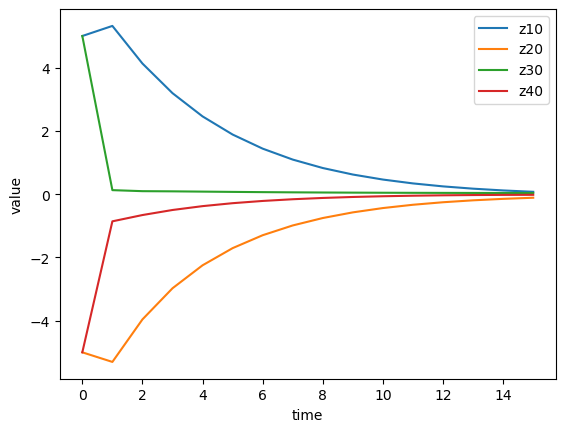

In [4]:
# Extract optimal state trajectories at the breakpoints (N+1 values, one per element boundary)
# m.iii = [0, 1, ..., N]; multiply by h=10 to convert indices to time in seconds
t = list(m.iii)

z10 = [pyo.value(m.z10[i]) for i in t]
z20 = [pyo.value(m.z20[i]) for i in t]
z30 = [pyo.value(m.z30[i]) for i in t]
z40 = [pyo.value(m.z40[i]) for i in t]

# Plot optimal state trajectories (deviations from steady state, cm)
plt.plot(t, z10, label='z10')
plt.plot(t, z20, label='z20')
plt.plot(t, z30, label='z30')
plt.plot(t, z40, label='z40')

plt.xlabel('time')
plt.ylabel('value')
plt.legend()
plt.show()

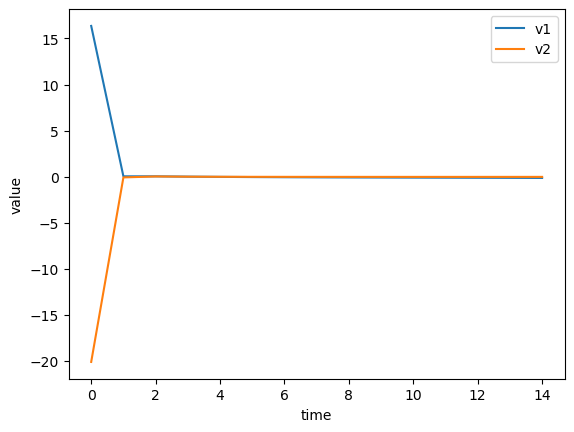

In [5]:
# Extract optimal control inputs (N values, one piecewise-constant value per finite element)
# m.i = [0, 1, ..., N-1]; multiply by h=10 to convert indices to time in seconds
t = list(m.i)

v1 = [pyo.value(m.v1[i]) for i in t]
v2 = [pyo.value(m.v2[i]) for i in t]

# Plot optimal control trajectories (deviations from steady-state pump flows, cm³/s)
plt.figure()  # new plot
plt.plot(t, v1, label='v1')
plt.plot(t, v2, label='v2')

plt.xlabel('time')
plt.ylabel('value')
plt.legend()
plt.show()